# Export NN force fields for LAMMPS

This notebook **only** exports the trained ForceGNN forces to files the
LAMMPS driver will read at runtime:

- `export_pair_table.py` → `pair_table_UD_Playing_3Tanh.table`
  for LAMMPS `pair_style table`.
- `export_env_grid.py` → `env_grid_UD_Playing_3Tanh.npz`
  for a `fix external pf/callback` lookup at each step.

The actual NN-driven simulation lives in
`Underdamped/Run_Underdamped_NN.ipynb` — once the files below exist, that
notebook can run independently.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

HERE = Path.cwd()
assert (HERE / 'export_pair_table.py').exists(), (
    f'Run this notebook from Export_Forces/. cwd is {HERE}'
)
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))
print('cwd =', HERE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
cwd = /Users/billiemeadowcroft/Dropbox/PostDocCode/MakeSimsFromForcefields/Export_Forces


## 1. Export F_pair(r) to LAMMPS table

**Why `rmin ≈ 0`?** The force is soft, so pair distances really can get
very small. `pair_style table` errors out if any pair sits below the
table's inner cutoff, so we extend the table all the way down. We use a
tiny `rmin=1e-6` rather than exactly zero only to avoid the (extremely
unlikely) case where two atoms are exactly coincident and LAMMPS would
divide by `r` computing the unit vector.

`n_points` bumped to 4000 so dr near zero stays small now that we cover
a wider range.

In [4]:
import export_pair_table

table_path = export_pair_table.main(
    rmin=1e-6,
    rmax=3.0,
    n_points=4000,
    keyword='FORCE_GNN_PAIR',
    out_name='pair_table_UD_Playing_3Tanh.table',
)
print('\nTable written to:', table_path)

Wrote /Users/billiemeadowcroft/Dropbox/PostDocCode/MakeSimsFromForcefields/Export_Forces/pair_table_UD_Playing_3Tanh.table
  keyword: FORCE_GNN_PAIR
  r range: [1e-06, 3.0]   N = 4000
  F(rmin) = -0.00665644   F(rmax) = -0.0110316
  U(rmin) = 0.695162   U(rmax) = 0
  also saved arrays to /Users/billiemeadowcroft/Dropbox/PostDocCode/MakeSimsFromForcefields/Export_Forces/pair_table_UD_Playing_3Tanh.npz

Table written to: /Users/billiemeadowcroft/Dropbox/PostDocCode/MakeSimsFromForcefields/Export_Forces/pair_table_UD_Playing_3Tanh.table


## 2. Verify pair table vs the live NN

Parses the `.table` back from disk (so we're plotting the exact numbers
LAMMPS will see) and overlays the live NN's `F_pair(r)`. If the curves
overlap, the export round-trips.

Worth eyeballing the `r → 0` end: the NN is extrapolating well outside
its training range (the original inference notebook plotted `r in [0.3, 3.5]`).
If the curve looks unphysical down there we can add a soft-core fit.

max |F_table - F_NN| = 2.247e-07


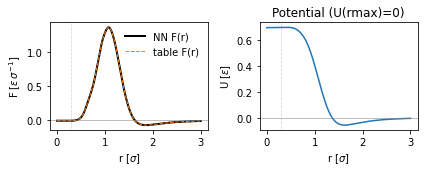

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import export_pair_table

TABLE_PATH = Path('pair_table_UD_Playing_3Tanh.table')
KEYWORD = 'FORCE_GNN_PAIR'


def read_lammps_pair_table(path, keyword):
    lines = path.read_text().splitlines()
    i = 0
    while i < len(lines) and lines[i].strip() != keyword:
        i += 1
    if i == len(lines):
        raise ValueError(f'keyword {keyword!r} not found in {path}')
    header = lines[i + 1].split()
    assert header[0] == 'N', f'unexpected header line: {lines[i+1]!r}'
    n_pts = int(header[1])
    j = i + 2
    while j < len(lines) and lines[j].strip() == '':
        j += 1
    rows = [lines[j + k].split() for k in range(n_pts)]
    r = np.array([float(row[1]) for row in rows])
    U = np.array([float(row[2]) for row in rows])
    F = np.array([float(row[3]) for row in rows])
    return r, U, F


r_tbl, U_tbl, F_tbl = read_lammps_pair_table(TABLE_PATH, KEYWORD)
model, norm = export_pair_table.load_trained_model()
F_nn = export_pair_table.f_pair(model, norm, r_tbl)
print(f'max |F_table - F_NN| = {np.max(np.abs(F_tbl - F_nn)):.3e}')

fig, (axF, axU) = plt.subplots(1, 2, figsize=(6, 2.5))
axF.plot(r_tbl, F_nn, color='black', lw=2, label='NN F(r)')
axF.plot(r_tbl, F_tbl, color='tab:orange', lw=1, ls='--', label='table F(r)')
axF.axhline(0, color='grey', lw=0.5)
axF.axvline(0.3, color='grey', lw=0.5, ls=':')  # ~lower end of NN training r
axF.set_xlabel(r'r [$\sigma$]'); axF.set_ylabel(r'F [$\epsilon\,\sigma^{-1}$]')
#axF.set_title('Pair force (dotted = ~training r_min)'); 
axF.legend(frameon=False)
axU.plot(r_tbl, U_tbl, color='tab:blue', lw=1.5)
axU.axhline(0, color='grey', lw=0.5)
axU.axvline(0.3, color='grey', lw=0.5, ls=':')
axU.set_xlabel(r'r [$\sigma$]'); axU.set_ylabel(r'U [$\epsilon$]')
axU.set_title('Potential (U(rmax)=0)')
fig.tight_layout(); plt.show()

## 3. Export F_env(x, y) to a 2D grid

Samples the env-net on a uniform grid over the full simulation box
(`[-20, 20]` in x and y, i.e. matching `box_size=40`). Saves `x_centers`,
`y_centers`, `Fx`, `Fy` to a `.npz` for the runtime LAMMPS callback to
load and bilinear-interpolate at each step.

In [6]:
import export_env_grid

env_path = export_env_grid.main(
    x_range=(-20.0,20.0),
    y_range=(-20.0, 20.0),
    nx=401,
    ny=401,
    out_name='env_grid_UD_Playing_3Tanh.npz',
)
print('\nGrid written to:', env_path)

Wrote /Users/billiemeadowcroft/Dropbox/PostDocCode/MakeSimsFromForcefields/Export_Forces/env_grid_UD_Playing_3Tanh.npz
  x in [-20.0, 20.0]  nx=401  dx=0.1
  y in [-20.0, 20.0]  ny=401  dy=0.1
  |F| min=0.009406  max=1.302  mean=1.134
  Fx range=[-1.214, 1.248]
  Fy range=[-0.8617, 0.9924]

Grid written to: /Users/billiemeadowcroft/Dropbox/PostDocCode/MakeSimsFromForcefields/Export_Forces/env_grid_UD_Playing_3Tanh.npz


## 4. Verify F_env grid vs the live NN

Two checks:
1. Plot the saved field as a heatmap + quiver — eyeball it against the
   `Fetch_ForceFields.ipynb` `F_env` plot.
2. Bilinear-interpolate the saved grid at 1000 random off-grid points and
   compare against the live NN. This is what LAMMPS will actually see.

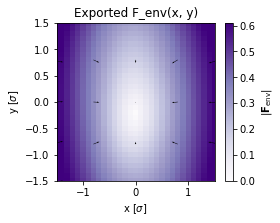

mean |F| = 0.9168   max |err_x|=0.0004141  |err_y|=0.000251


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import export_env_grid

GRID_PATH = Path('env_grid_UD_Playing_3Tanh.npz')
grid = np.load(GRID_PATH, allow_pickle=True)
x_c = grid['x_centers']; y_c = grid['y_centers']
Fx = grid['Fx']; Fy = grid['Fy']

X, Y = np.meshgrid(x_c, y_c, indexing='ij')
F_mag = np.sqrt(Fx**2 + Fy**2)
fig, ax = plt.subplots(figsize=(4, 3.2))
pcm = ax.pcolormesh(X, Y, F_mag, shading='auto', cmap='Purples',vmin=0,vmax=0.61)
fig.colorbar(pcm, ax=ax, label=r'$|\mathbf{F}_{\mathrm{env}}|$')
step = max(len(x_c) // 50, 1)
ax.quiver(X[::step, ::step], Y[::step, ::step], Fx[::step, ::step], Fy[::step, ::step],
          color='k', angles='xy', scale_units='xy', width=0.003,scale=3)
ax.set_xlabel(r'x [$\sigma$]'); ax.set_ylabel(r'y [$\sigma$]')
ax.set_aspect('equal'); ax.set_title('Exported F_env(x, y)')
ax.set_ylim([-1.5,1.5])
ax.set_xlim([-1.5,1.5])

fig.tight_layout(); plt.show()

rng = np.random.default_rng(0)
M = 1000
xq = rng.uniform(-5.0, 5.0, M); yq = rng.uniform(-5.0, 5.0, M)
Fx_i, Fy_i = export_env_grid.bilinear_interp_field(xq, yq, x_c, y_c, Fx, Fy)
model, norm = export_env_grid.load_trained_model()
F_true = export_env_grid.f_env(model, norm, np.stack([xq, yq], axis=1))
err_x = np.abs(Fx_i - F_true[:, 0]); err_y = np.abs(Fy_i - F_true[:, 1])
scale = np.sqrt(F_true[:, 0]**2 + F_true[:, 1]**2).mean()
print(f'mean |F| = {scale:.4g}   '
      f'max |err_x|={err_x.max():.4g}  |err_y|={err_y.max():.4g}')

When both files are written and verified, open
`Underdamped/Run_Underdamped_NN.ipynb` to drive a LAMMPS sim that uses them.